# Lab 1 · Part 2 — Inside the model: opening the black box
### EUROCONTROL AI Lab · Exercise 1, Part 2

In Part 1 we trained a neural network that forecasts **tomorrow's number of IFR movements at Brussels (EBBR)** from the traffic of the last days and the day of the week.
Here we open it:

- **Part A — What the model really is:** we draw the network, look at all its numbers, and follow one forecast step by step.
- **Part B — Why did it forecast that?** Simple *explainability* methods: which inputs matter, what happens if we change them, and why the model gave one particular forecast.

| | |
|---|---|
| ⏱ **Time** | about 50 minutes |
| 🎓 **Prerequisites** | run **Part 1** first: its section 8.1 saves the trained model in the `artifacts` folder |

**What you will learn**
1. A neural network is just a list of numbers (the **weights**) combined with multiplications, additions and a simple on/off rule.
2. Why reading those numbers directly does not tell us *why* the model forecasts what it does.
3. Three simple ways to **explain** a forecast: importance of the inputs, "what-if" experiments, and the explanation of a single day.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, use *Kernel → Restart Kernel and Run All Cells*.
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

>
> 🧑‍💻 **Optional coding challenges** — a few cells invite those who want to **write code** to try a variation of the exercise.
> They are clearly marked, **switched off** (every line starts with `#`, so running them does nothing) and the rest of the notebook does not depend on them: skip them freely.
> To try one, remove the `#` signs (select the lines and press **Ctrl + /**, or **Cmd + /** on a Mac), fill in the `___` blanks and run the cell.
> The solutions are in the `solutions` folder next to this notebook.

> ✅ **SOLUTIONS NOTEBOOK** — identical to the participant notebook, except that the **optional coding challenges** (🧑‍💻) are solved and executed. Search for 🧑‍💻 to jump to them.

---
## 0 · Setup: load the trained model and the data

In [1]:
import sys                                        # sys: lets Python find our shared file
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import seaborn as sns                             # seaborn: heatmaps
import torch                                      # PyTorch: neural networks
from matplotlib.lines import Line2D               # Line2D: sample lines for legends

LAB_DIR = Path(".").resolve()                     # this lab's folder (as a full path)...
if not (LAB_DIR / "traffic_core.py").exists():    # ...or, from the solutions folder...
    LAB_DIR = LAB_DIR.parent                      # ...the folder above
sys.path.insert(0, str(LAB_DIR))                  # let Python find traffic_core.py
import traffic_core                               # the shared code (same definitions as Part 1)

saved = traffic_core.SavedTrafficModel(LAB_DIR / "artifacts")   # load the model saved at the end of Part 1
model = saved.model                               # the neural network itself
LOOKBACK = saved.lookback                         # how many past days it uses
NAMES = traffic_core.input_names(LOOKBACK)        # readable names of its inputs

series = traffic_core.load_series(LAB_DIR.parent / "data", saved.card["airport"])   # the daily traffic, 2023–2025
X_raw, y_true, dates = traffic_core.make_examples(series, LOOKBACK)   # all the examples (inputs not scaled)
is_test = dates >= "2025-07-01"                   # the test period used in Part 1
is_train = dates < "2025-01-01"                   # the training period used in Part 1

print("Model:", saved.card["name"])               # which model
print("Inputs:", LOOKBACK, "past days + 7 weekday switches =", LOOKBACK + 7, "numbers")   # its inputs
print("Test error in Part 1:", saved.card["test_mae"], "flights per day")                 # its test error

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

Model: Next-day IFR traffic forecast EBBR
Inputs: 7 past days + 7 weekday switches = 14 numbers
Test error in Part 1: 19.4 flights per day


---
# Part A — What the model really is

## 1 · The whole network in one picture
Every circle is a **neuron**, every line a **weight** — a number learned during training.

The whole model is 1569 numbers


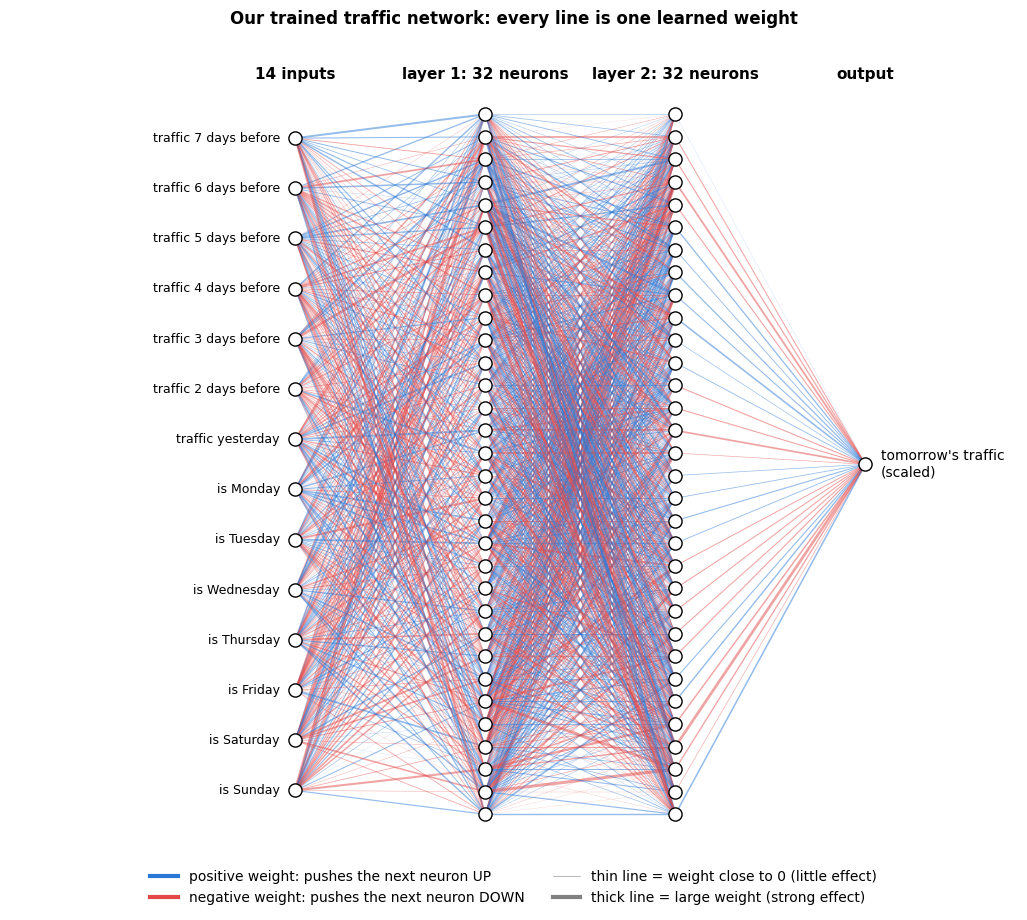

In [2]:
W1 = model.layers[0].weight.detach().numpy()       # weights of layer 1: one row per neuron, one column per input
W2 = model.layers[2].weight.detach().numpy()       # weights of layer 2: neurons of layer 2 x neurons of layer 1
W3 = model.layers[4].weight.detach().numpy()       # weights of the output: 1 row x neurons of layer 2
b1 = model.layers[0].bias.detach().numpy()         # one extra number (bias) per neuron of layer 1
b2 = model.layers[2].bias.detach().numpy()         # biases of layer 2
b3 = model.layers[4].bias.detach().numpy()         # bias of the output
HIDDEN = W1.shape[0]                               # neurons per layer

total = W1.size + W2.size + W3.size + b1.size + b2.size + b3.size   # count all the numbers
print("The whole model is", total, "numbers")      # show the total

layer_sizes = [LOOKBACK + 7, HIDDEN, HIDDEN, 1]    # neurons in each column of the drawing
weight_tables = [W1, W2, W3]                       # the connections between consecutive columns
largest = max(np.abs(W1).max(), np.abs(W2).max(), np.abs(W3).max())   # the largest weight, to scale line widths
spacing = [1.0, 0.45, 0.45, 1.0]                   # vertical distance between neurons in each column


def y_position(i, column):                         # vertical position of neuron i in a given column
    n = layer_sizes[column]                        # how many neurons in that column
    return ((n - 1) / 2 - i) * spacing[column]     # centred around 0


plt.figure(figsize=(13, 10))                       # new figure
for column in range(3):                            # for each group of connections...
    table = weight_tables[column]                  # ...its weight table
    for j in range(table.shape[0]):                # for each neuron on the right side...
        for i in range(table.shape[1]):            # ...and each neuron on the left side:
            w = table[j, i]                        # the weight connecting them
            if w > 0:                              # positive weight...
                colour = PALETTE[0]                # ...blue
            else:                                  # negative weight...
                colour = PALETTE[7]                # ...red
            width = 0.1 + 2.5 * abs(w) / largest   # thicker line = larger weight
            plt.plot([column, column + 1], [y_position(i, column), y_position(j, column + 1)],
                     color=colour, linewidth=width, alpha=0.5)   # draw the line
for column in range(4):                            # draw the neurons as circles
    for i in range(layer_sizes[column]):           # for each neuron of the column
        plt.scatter(column, y_position(i, column), s=90, color="white", edgecolor="black", zorder=3)   # a circle
for i in range(LOOKBACK + 7):                      # write the name of each input on the left
    plt.text(-0.08, y_position(i, 0), NAMES[i], ha="right", va="center", fontsize=9)   # input name
plt.text(3.08, 0, "tomorrow's traffic\n(scaled)", ha="left", va="center", fontsize=10)   # output label
titles = [str(LOOKBACK + 7) + " inputs", "layer 1: " + str(HIDDEN) + " neurons", "layer 2: " + str(HIDDEN) + " neurons", "output"]   # column titles
for column in range(4):                            # write the title above each column
    plt.text(column, y_position(0, 1) + 0.7, titles[column], ha="center", fontsize=11, fontweight="bold")   # column title
legend_lines = [                                   # the entries of the legend:
    Line2D([0], [0], color=PALETTE[0], linewidth=3, label="positive weight: pushes the next neuron UP"),     # blue
    Line2D([0], [0], color=PALETTE[7], linewidth=3, label="negative weight: pushes the next neuron DOWN"),   # red
    Line2D([0], [0], color="grey", linewidth=0.4, label="thin line = weight close to 0 (little effect)"),    # thin
    Line2D([0], [0], color="grey", linewidth=3, label="thick line = large weight (strong effect)"),          # thick
]                                                  # (end of the legend entries)
plt.legend(handles=legend_lines, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=2, fontsize=10)   # legend below
plt.axis("off")                                    # no axes
plt.xlim(-1.5, 3.8)                                # space for the labels
plt.title("Our trained traffic network: every line is one learned weight", pad=40)   # title
plt.show()                                         # display

📖 **How to read the drawing:** information flows **from left to right**. Each line multiplies the value on its left by its weight and passes it on.
**Blue** = positive weight (pushes the next neuron up), **red** = negative (pushes it down); **thicker** = larger weight. (Each neuron also has one extra number, the *bias*, not drawn.)

📖 **Reading:** this is the **entire** model — about 1 500 numbers. Nothing else is hidden. But even with every line in front of us, we cannot say *why* it forecasts 540 rather than 600 flights.

## 2 · The weight tables
The same numbers as three tables. **Each coloured square is one weight**; the colour scale on the right gives its value (**blue = positive, red = negative, white ≈ 0**), the same for the three tables.

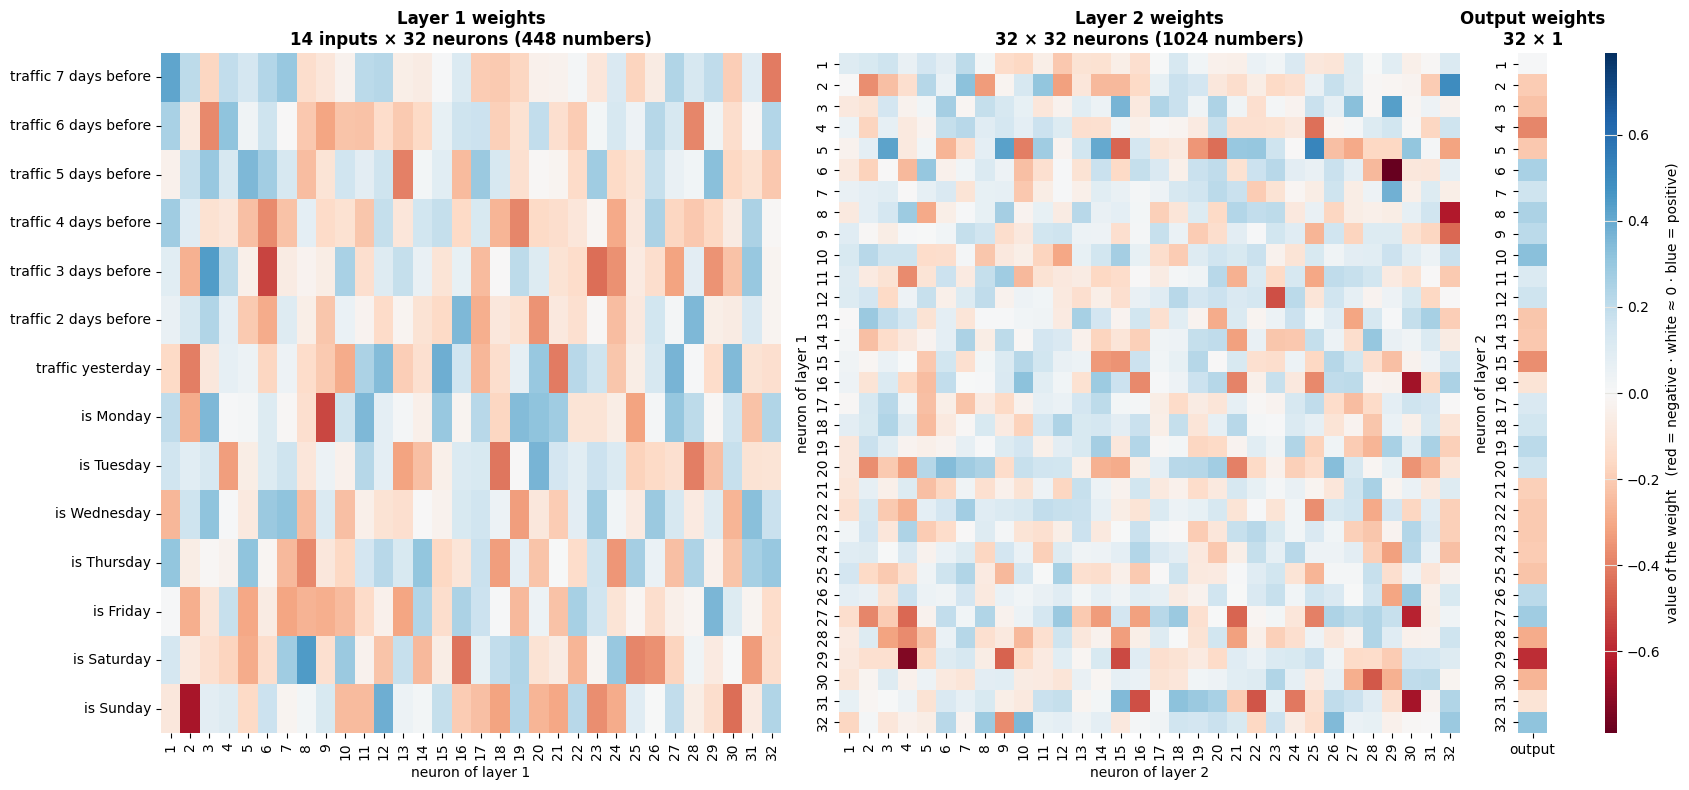

In [3]:
limit = max(np.abs(W1).max(), np.abs(W2).max(), np.abs(W3).max())   # one colour scale for all tables
neuron_labels = []                                        # labels 1, 2, 3, ... for the neurons
for i in range(1, HIDDEN + 1):                            # for each neuron number...
    neuron_labels.append(i)                               # ...add it to the list
fig, axes = plt.subplots(1, 4, figsize=(17, 8), gridspec_kw={"width_ratios": [HIDDEN, HIDDEN, 1.5, 0.6]})   # 3 tables + scale

sns.heatmap(W1.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[0], cbar=False,
            yticklabels=NAMES, xticklabels=neuron_labels) # rows = the inputs, columns = the neurons of layer 1
axes[0].set_title("Layer 1 weights\n" + str(LOOKBACK + 7) + " inputs × " + str(HIDDEN) + " neurons (" + str(W1.size) + " numbers)")   # title
axes[0].set_xlabel("neuron of layer 1")                   # axis label

sns.heatmap(W2.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[1], cbar=False,
            yticklabels=neuron_labels, xticklabels=neuron_labels)   # rows = layer-1 neurons, columns = layer-2 neurons
axes[1].set_title("Layer 2 weights\n" + str(HIDDEN) + " × " + str(HIDDEN) + " neurons (" + str(W2.size) + " numbers)")   # title
axes[1].set_xlabel("neuron of layer 2")                   # axis label
axes[1].set_ylabel("neuron of layer 1")                   # axis label

sns.heatmap(W3.T, cmap="RdBu", vmin=-limit, vmax=limit, ax=axes[2], cbar_ax=axes[3], yticklabels=neuron_labels, xticklabels=["output"],
            cbar_kws={"label": "value of the weight   (red = negative · white ≈ 0 · blue = positive)"})   # + colour scale
axes[2].set_title("Output weights\n" + str(HIDDEN) + " × 1")   # title
axes[2].set_ylabel("neuron of layer 2")                   # axis label

for ax in axes[:3]:                                       # for each table...
    ax.grid(False)                                        # ...no grid lines
plt.tight_layout()                                        # adjust spacing
plt.show()                                                # display

| Table | Size | One square is… |
|---|---|---|
| Layer 1 | inputs × neurons | the weight from one **input** (a past day or a weekday switch) to one neuron of layer 1 |
| Layer 2 | neurons × neurons | the weight from one neuron of layer 1 to one neuron of layer 2 |
| Output | neurons × 1 | the weight from one neuron of layer 2 to the forecast (PyTorch stores it as 1 × neurons; we draw it turned on its side as a column) |

📖 **Reading:**
- **Layer 1** is the only table with **named rows**: you can see, for example, whether the "is Saturday" switch has strong weights, or whether "traffic 7 days before" matters more than "traffic yesterday".
- In **layer 2** and the **output**, both sides are anonymous neurons: the colours cannot be interpreted. After the first layer the inputs are mixed together.
- That is why, to understand *why* a model forecasts something, we look at it **from the outside** (Part B).

## 3 · Following one forecast through the network
We take one real day of the test period: **Saturday 13 September 2025**.

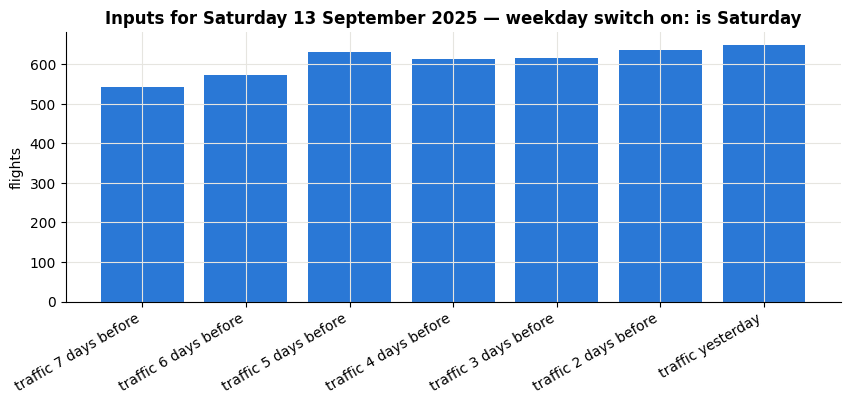

True traffic that day: 534 flights


In [4]:
DAY = pd.Timestamp("2025-09-13")                   # the day we forecast
row = int(np.where(dates == DAY)[0][0])            # its position in the list of examples
x_raw = X_raw[row]                                 # its inputs, in flights and 0/1 switches

past_labels = NAMES[:LOOKBACK]                     # names of the past days
plt.figure(figsize=(10, 3.5))                      # new figure
plt.bar(past_labels, x_raw[:LOOKBACK], color=PALETTE[0])   # the traffic of the past days
plt.xticks(rotation=30, ha="right")                # tilt the labels so they can be read
plt.ylabel("flights")                              # axis label
plt.title("Inputs for " + DAY.strftime("%A %d %B %Y") + " — weekday switch on: " + NAMES[LOOKBACK + DAY.dayofweek])   # title
plt.show()                                         # display
print("True traffic that day:", int(y_true[row]), "flights")   # what really happened

**Step 1 — scaling:** the traffic numbers become *"how far from the usual traffic"* (the weekday switches stay 0 or 1). **Step 2 — layer by layer**, by hand:

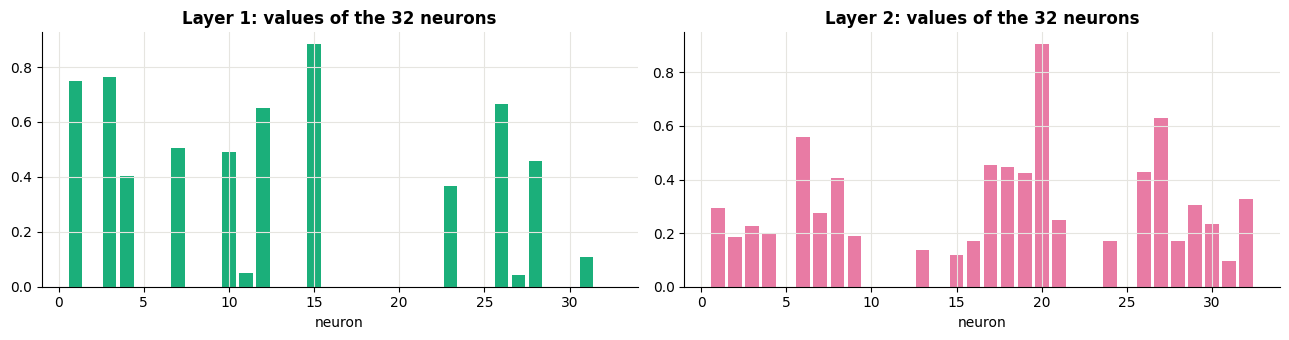

Output (scaled): 0.38
Forecast by hand : 549.8 flights
Forecast PyTorch : 549.8 flights
True traffic     : 534 flights · baseline (same day last week): 542


In [5]:
x = saved.scale(X_raw[row:row + 1])[0]             # the scaled inputs of this day
z1 = W1 @ x + b1                                   # layer 1: weighted sums of the inputs (@ = "multiply by the table")
h1 = np.maximum(z1, 0)                             # ReLU: negative values become 0
z2 = W2 @ h1 + b2                                  # layer 2: weighted sums of the values of layer 1
h2 = np.maximum(z2, 0)                             # ReLU again
output = float((W3 @ h2 + b3)[0])                  # the output: one number (scaled)
flights = output * saved.std + saved.mean          # undo the scaling: back to flights

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))  # two plots side by side
axes[0].bar(range(1, HIDDEN + 1), h1, color=PALETTE[2])   # values of the neurons of layer 1
axes[0].set_title("Layer 1: values of the " + str(HIDDEN) + " neurons")   # title
axes[0].set_xlabel("neuron")                       # axis label
axes[1].bar(range(1, HIDDEN + 1), h2, color=PALETTE[4])   # values of the neurons of layer 2
axes[1].set_title("Layer 2: values of the " + str(HIDDEN) + " neurons")   # title
axes[1].set_xlabel("neuron")                       # axis label
plt.tight_layout()                                 # adjust spacing
plt.show()                                         # display

print("Output (scaled):", round(output, 3))        # the raw output
print("Forecast by hand :", round(flights, 1), "flights")   # our own calculation
print("Forecast PyTorch :", round(float(saved.forecast_many(X_raw[row:row + 1])[0]), 1), "flights")   # the same by the model
print("True traffic     :", int(y_true[row]), "flights · baseline (same day last week):", int(x_raw[LOOKBACK - 7]))   # comparison

📖 **Reading:** many neurons are 0 (switched off by ReLU for this day). Our hand calculation gives **exactly the same forecast as PyTorch**: only multiplications and additions.

**Zoom on one neuron** of layer 1 — the most active one — computed term by term:

In [6]:
n = int(np.argmax(h1))                             # the most active neuron of layer 1
terms = pd.DataFrame()                             # a table of the calculation
terms["input"] = NAMES                             # the inputs
terms["scaled value"] = x.round(3)                 # their scaled values
terms["weight"] = W1[n].round(3)                   # the weights of this neuron
terms["weight × value"] = (W1[n] * x).round(3)     # each product
print("Neuron", n + 1, "of layer 1: sum", round(float(np.sum(W1[n] * x)), 3), "+ bias", round(float(b1[n]), 3),
      "=", round(float(z1[n]), 3), "→ after ReLU", round(float(h1[n]), 3))   # the result
terms                                              # display the table

Neuron 15 of layer 1: sum 0.659 + bias 0.223 = 0.882 → after ReLU 0.882


,input,scaled value,weight,weight × value
0,traffic 7 days before,0.269,0.011,0.003
1,traffic 6 days before,0.708,0.067,0.047
2,traffic 5 days before,1.531,0.087,0.133
3,traffic 4 days before,1.276,0.187,0.238
4,traffic 3 days before,1.332,-0.110,-0.146
5,traffic 2 days before,1.588,-0.154,-0.245
6,traffic yesterday,1.786,0.385,0.688
7,is Monday,0.000,0.301,0.000
8,is Tuesday,0.000,-0.048,-0.000
9,is Wednesday,0.000,-0.033,-0.000


## 4 · What did training change?
We compare the trained network with the **same network before training** (random weights) on the test period.

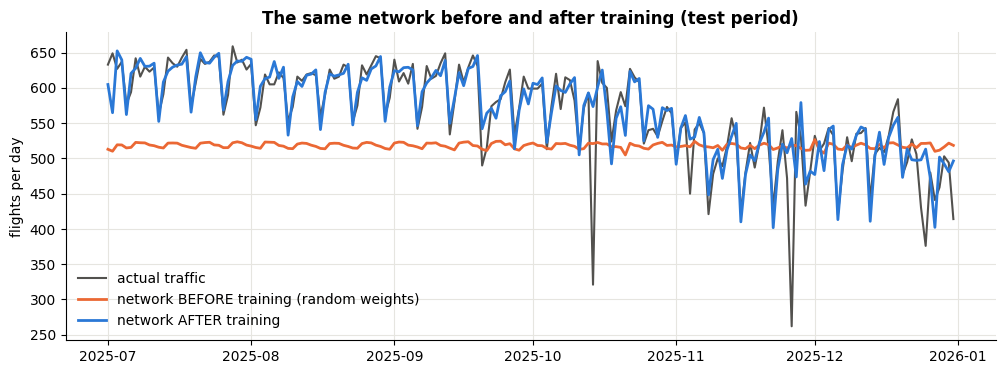

In [7]:
torch.manual_seed(0)                               # fixed random start
untrained = traffic_core.TrafficMLP(LOOKBACK + 7, HIDDEN)   # same structure, random weights
untrained.eval()                                   # evaluation mode
with torch.no_grad():                              # prediction only
    untrained_scaled = untrained(torch.tensor(saved.scale(X_raw[is_test]))).numpy()   # untrained outputs
untrained_flights = untrained_scaled * saved.std + saved.mean   # back to flights
trained_flights = saved.forecast_many(X_raw[is_test])           # trained forecasts

plt.figure(figsize=(12, 4))                        # new figure
plt.plot(dates[is_test], y_true[is_test], color="#52514e", linewidth=1.5, label="actual traffic")   # reality
plt.plot(dates[is_test], untrained_flights, color=PALETTE[1], label="network BEFORE training (random weights)")   # untrained
plt.plot(dates[is_test], trained_flights, color=PALETTE[0], label="network AFTER training")   # trained
plt.ylabel("flights per day")                      # axis label
plt.title("The same network before and after training (test period)")   # title
plt.legend()                                       # legend
plt.show()                                         # display

📖 **Reading:** before training the network gives almost the same number every day. After training it follows the weekly rhythm. **Training only changed the numbers** drawn in §1.

---
# Part B — Why did it forecast that? (explainability)

## 5 · Which inputs matter most?
We **shuffle** one input over all the test days (its values stay realistic but no longer belong to the right day) and measure how much the **average error grows**.
The 7 weekday switches are shuffled together, as one piece of information.

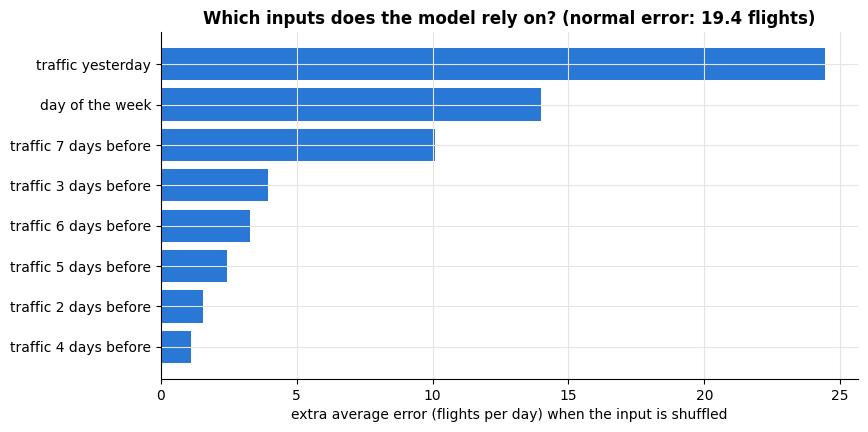

In [8]:
groups = {}                                        # the inputs, grouped as people think about them
for k in range(LOOKBACK):                          # each past day is its own group...
    groups[NAMES[k]] = [k]                         # ...(one column)
groups["day of the week"] = list(range(LOOKBACK, LOOKBACK + 7))   # the 7 switches together

X_test = X_raw[is_test]                            # the test inputs
truth = y_true[is_test]                            # the true traffic
normal_error = float(np.mean(np.abs(saved.forecast_many(X_test) - truth)))   # the normal average error

rng = np.random.default_rng(42)                    # random-number generator with a fixed seed
extra_error = {}                                   # extra error for each group
for name in groups:                                # for each group...
    shuffled = X_test.copy()                       # ...copy the test inputs...
    order = rng.permutation(len(shuffled))         # ...draw a random order of the days...
    for column in groups[name]:                    # ...and for each column of the group...
        shuffled[:, column] = X_test[order, column]   # ...shuffle it (same order for the 7 switches)
    error = float(np.mean(np.abs(saved.forecast_many(shuffled) - truth)))   # the new average error
    extra_error[name] = error - normal_error       # how much worse without this information

importance = pd.Series(extra_error).sort_values()  # sort from least to most important
plt.figure(figsize=(9, 4.5))                       # new figure
plt.barh(importance.index, importance.values, color=PALETTE[0])   # one bar per input
plt.xlabel("extra average error (flights per day) when the input is shuffled")   # axis label
plt.title("Which inputs does the model rely on? (normal error: " + str(round(normal_error, 1)) + " flights)")   # title
plt.show()                                         # display

📖 **Reading:** the longer the bar, the more the forecast depends on that input. The model relies most on **yesterday's traffic** (the current level),
then on the **day of the week** and on **the same day last week** — the two pieces of information that the scatter plots of Part 1 (§2.6) showed to be most useful.
The other past days add little.

## 6 · What-if experiments
We take the real inputs of Saturday 13 September 2025 and change them on purpose.

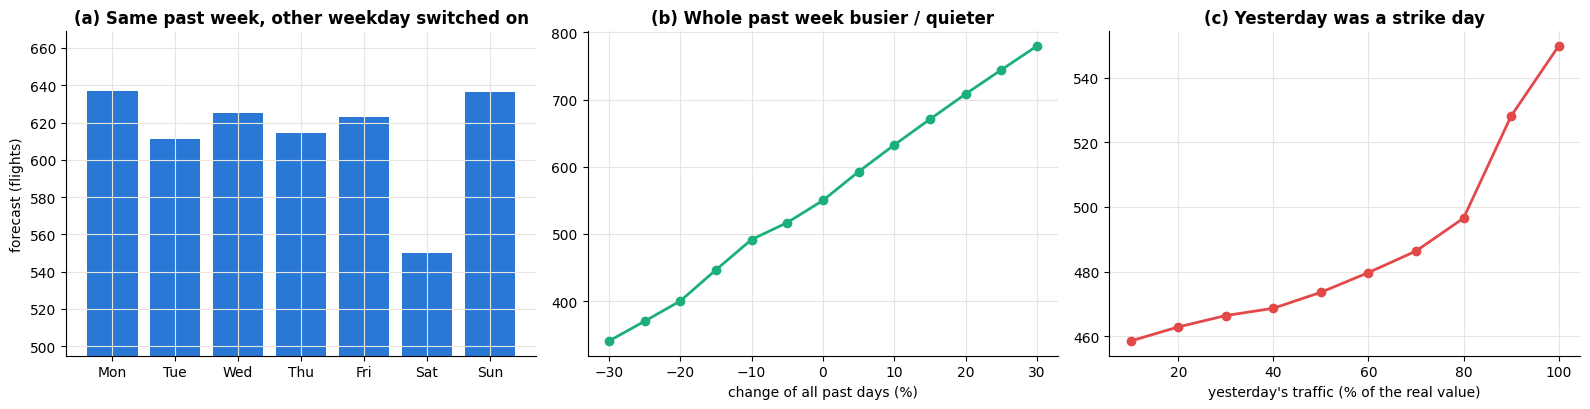

In [9]:
base = X_raw[row].copy()                           # the real inputs of our day

weekday_forecasts = []                             # (a) same past days, but pretend tomorrow is another weekday
for d in range(7):                                 # for Monday ... Sunday
    changed = base.copy()                          # copy the inputs
    changed[LOOKBACK:] = 0.0                       # switch off all weekday switches...
    changed[LOOKBACK + d] = 1.0                    # ...and switch on weekday d
    weekday_forecasts.append(float(saved.forecast_many(changed.reshape(1, -1))[0]))   # the forecast

factors = np.arange(0.7, 1.31, 0.05)               # (b) the whole past week 30 % lower ... 30 % higher
week_forecasts = []                                # the forecasts
for f in factors:                                  # for each factor
    changed = base.copy()                          # copy the inputs
    changed[:LOOKBACK] = base[:LOOKBACK] * f       # multiply all the past traffic
    week_forecasts.append(float(saved.forecast_many(changed.reshape(1, -1))[0]))   # the forecast

strike_levels = np.arange(0.1, 1.01, 0.1)          # (c) yesterday was a strike: only 10 % … 100 % of its traffic
strike_forecasts = []                              # the forecasts
for s in strike_levels:                            # for each level
    changed = base.copy()                          # copy the inputs
    changed[LOOKBACK - 1] = base[LOOKBACK - 1] * s # reduce only yesterday's traffic
    strike_forecasts.append(float(saved.forecast_many(changed.reshape(1, -1))[0]))   # the forecast

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))  # three plots
short_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]   # short weekday names
axes[0].bar(short_days, weekday_forecasts, color=PALETTE[0])      # (a)
axes[0].set_title("(a) Same past week, other weekday switched on")   # title
axes[0].set_ylabel("forecast (flights)")           # axis label
axes[0].set_ylim(min(weekday_forecasts) * 0.9, max(weekday_forecasts) * 1.05)   # zoom on the differences
axes[1].plot((factors - 1) * 100, week_forecasts, marker="o", color=PALETTE[2])   # (b)
axes[1].set_title("(b) Whole past week busier / quieter")   # title
axes[1].set_xlabel("change of all past days (%)")  # axis label
axes[2].plot(strike_levels * 100, strike_forecasts, marker="o", color=PALETTE[7])   # (c)
axes[2].set_title("(c) Yesterday was a strike day")   # title
axes[2].set_xlabel("yesterday's traffic (% of the real value)")   # axis label
plt.tight_layout()                                 # adjust spacing
plt.show()                                         # display

📖 **Reading:**
- **(a)** With the same past days, only the weekday switch changes the forecast — this is how the model uses the 7 switches of Part 1, §4.1. Saturday should be clearly the lowest.
- **(b)** If the whole past week were busier, the forecast rises: the model follows the recent *level* of traffic.
- **(c)** If yesterday had been a strike (only 10 % of its traffic), the model lowers tomorrow's forecast by almost 100 flights — although traffic usually returns
  to normal the day after a strike. The model **over-reacts** to disruptions in its inputs. You will meet a real case in the task of §8 (the day after 26 November 2025).
  This is exactly the kind of behaviour an operational user would want to know before trusting the forecast.

### 🧑‍💻 Optional coding challenge — change only "the same day last week"
*Optional, for those who want to write code.*

**Task:** like experiment (c), change **only** the traffic of 7 days before (column `LOOKBACK - 7`) from 50 % to 150 % of its real value and draw the forecast.
Compare with (c): which of the two days does the model follow more?

Solution: `solutions/Lab1_part2_inside_the_model_SOLUTIONS.ipynb`

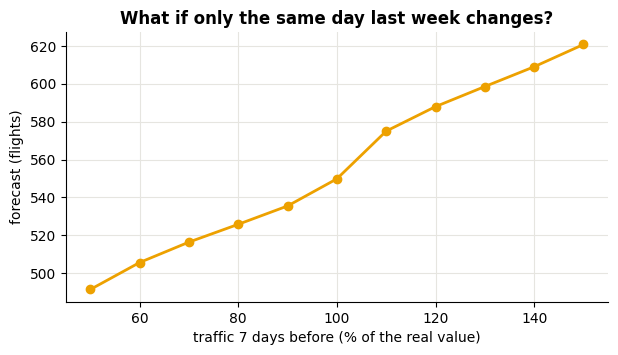

In [10]:
# 🧑‍💻 OPTIONAL CHALLENGE — SOLUTION
levels = np.arange(0.5, 1.51, 0.1)                           # 50 % ... 150 %
forecasts = []                                               # the forecasts
for level in levels:                                         # for each level...
    changed = base.copy()                                    # ...copy the inputs...
    changed[LOOKBACK - 7] = base[LOOKBACK - 7] * level       # ...change only "7 days before"...
    forecasts.append(float(saved.forecast_many(changed.reshape(1, -1))[0]))   # ...and forecast

plt.figure(figsize=(7, 3.5))                                 # new figure
plt.plot(levels * 100, forecasts, marker="o", color=PALETTE[3])   # the curve
plt.xlabel("traffic 7 days before (% of the real value)")    # axis label
plt.ylabel("forecast (flights)")                             # axis label
plt.title("What if only the same day last week changes?")    # title
plt.show()                                                   # display

## 7 · Explaining one single forecast
For one day we replace each input in turn with its value from **300 other, randomly chosen days** of the training period, keeping the others, and average the forecasts.
The difference tells us how much that input **raised** (red) or **lowered** (blue) the forecast, in flights.

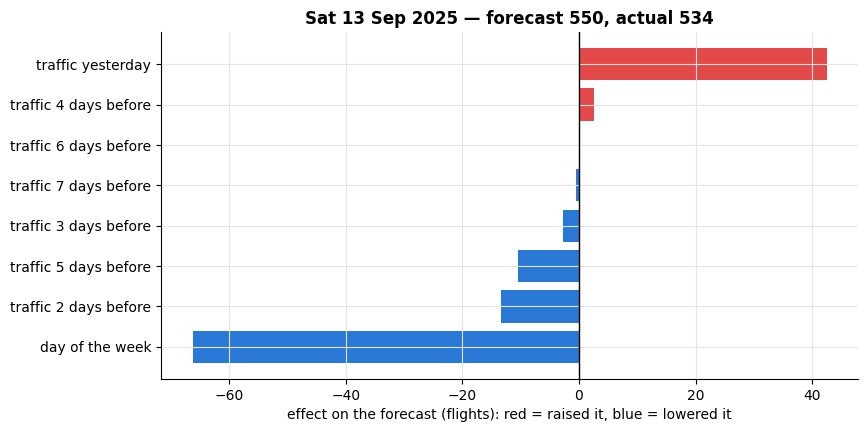

Past traffic (oldest → yesterday): [542, 573, 631, 613, 617, 635, 649]


In [11]:
training_inputs = X_raw[is_train]                  # the inputs of all the training days
rng_ref = np.random.default_rng(1)                 # random-number generator with a fixed seed
chosen_rows = rng_ref.choice(len(training_inputs), 300, replace=False)   # 300 different training days, at random
references = training_inputs[chosen_rows]          # their inputs: our 300 reference days


def explain_day(day):                              # explains the model's forecast for one day of the data
    day = pd.Timestamp(day)                        # the day as a date
    r = int(np.where(dates == day)[0][0])          # its position in the list of examples
    x_day = X_raw[r]                               # its inputs
    forecast = float(saved.forecast_many(x_day.reshape(1, -1))[0])   # the model's forecast
    effects = {}                                   # how much each group moves the forecast
    for name in groups:                            # for each group of inputs...
        copies = np.tile(x_day, (len(references), 1))   # ...300 copies of our day...
        for column in groups[name]:                # ...in which the columns of this group...
            copies[:, column] = references[:, column]   # ...take the values of the reference days
        effects[name] = forecast - float(saved.forecast_many(copies).mean())   # + = this input raised the forecast
    effects = pd.Series(effects).sort_values()     # sort the effects
    colours = []                                   # one colour per bar
    for value in effects.values:                   # for each effect...
        if value > 0:                              # ...raising the forecast...
            colours.append(PALETTE[7])             # ...red
        else:                                      # ...lowering it...
            colours.append(PALETTE[0])             # ...blue
    plt.figure(figsize=(9, 4.5))                   # new figure
    plt.barh(effects.index, effects.values, color=colours)   # one bar per input group
    plt.axvline(0, color="black", linewidth=1)     # the zero line
    plt.xlabel("effect on the forecast (flights): red = raised it, blue = lowered it")   # axis label
    plt.title(day.strftime("%a %d %b %Y") + " — forecast " + str(round(forecast)) + ", actual " + str(int(y_true[r])))   # title
    plt.show()                                     # display
    past = []                                      # the past traffic as whole numbers
    for value in x_day[:LOOKBACK]:                 # for each past day...
        past.append(int(value))                    # ...its traffic
    print("Past traffic (oldest → yesterday):", past)   # show the inputs


explain_day("2025-09-13")                          # explain our Saturday

📖 **Reading:** for this Saturday the **"day of the week"** bar should lower the forecast strongly (Saturdays are quiet), while the past days raise or lower it depending on
whether they were busier or quieter than usual. The bars tell us **what the model used** — not necessarily the real causes of traffic.

---
## 8 · Your task: be the analyst
Below are real test days where the model was **very accurate**, **far too high** (forecast above reality) or **far too low**.

In [12]:
errors = saved.forecast_many(X_raw[is_test]) - y_true[is_test]   # forecast minus reality, for each test day
test_days = dates[is_test]                         # the test dates
order = np.argsort(errors)                         # positions sorted from most negative to most positive error
closest = np.argsort(np.abs(errors))               # positions sorted from smallest to largest error

print("VERY ACCURATE:")                            # title
for p in closest[:3]:                              # the 3 smallest errors
    print("   ", test_days[p].date(), test_days[p].day_name(), " error", round(float(errors[p])), "flights")
print("FORECAST FAR TOO HIGH:")                    # title
for p in order[::-1][:3]:                          # the 3 largest positive errors
    print("   ", test_days[p].date(), test_days[p].day_name(), " error +" + str(round(float(errors[p]))), "flights")
print("FORECAST FAR TOO LOW:")                     # title
for p in order[:3]:                                # the 3 largest negative errors
    print("   ", test_days[p].date(), test_days[p].day_name(), " error", round(float(errors[p])), "flights")

VERY ACCURATE:
    2025-11-02 Sunday  error 0 flights
    2025-10-13 Monday  error 0 flights
    2025-11-07 Friday  error 0 flights
FORECAST FAR TOO HIGH:
    2025-11-26 Wednesday  error +266 flights
    2025-10-14 Tuesday  error +253 flights
    2025-12-25 Thursday  error +137 flights
FORECAST FAR TOO LOW:
    2025-11-27 Thursday  error -92 flights
    2025-07-02 Wednesday  error -84 flights
    2025-12-01 Monday  error -55 flights


**Task (no coding needed):**
1. Copy one of the dates above into the cell below (between the quotes) and run it. Try at least one date from each list.
2. For each one, answer:
   - Which inputs raised the forecast, and which lowered it?
   - For the "far too high" days: what happened that day (strike? holiday?) — could any of the inputs have warned the model?
   - For the "far too low" days: look at the past traffic printed below the chart — was there a disruption in the previous days that the model over-reacted to?
   - Would you trust this forecast in operations? What extra information would you give the model?

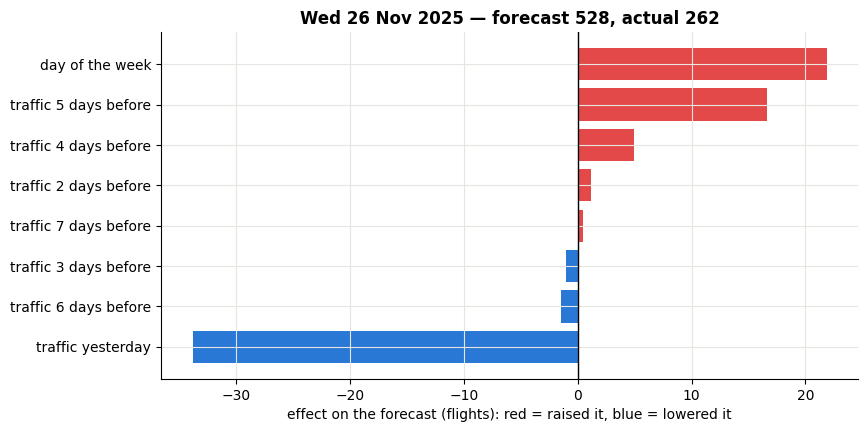

Past traffic (oldest → yesterday): [521, 572, 516, 432, 496, 540, 472]


In [13]:
CHOSEN_DAY = str(test_days[order[::-1][0]].date()) # ← replace with a date from the lists above, e.g. "2025-11-26"
explain_day(CHOSEN_DAY)                            # explain the model's forecast for that day

---
## 9 · Questions for discussion
1. We can see every single number of the model. Why is that not enough to understand it?
2. The model follows the recent traffic level. Is that a strength or a weakness on the day after a strike?
3. What would an ATFM or airport planner need to see, next to the forecast, before using it?

➡️ **Next: Part 3 — the model as a service** (`Lab1_part3_serve.ipynb`).